# 05_enedis_merge.ipynb

### Objectif :

Ce notebook a pour objectif de **lier les données ADEME (DPE) avec les données Enedis de consommation réelle**  
afin de créer un dataset enrichi au niveau **IRIS (zones géographiques INSEE)**.

> Étapes principales :
> 1. Chargement et nettoyage des données ADEME et Enedis  
> 2. Association spatiale des logements ADEME à un IRIS  
> 3. Agrégation des données Enedis par IRIS  
> 4. Fusion des deux sources  
> 5. Vérifications, visualisations et export du dataset final


### 01. Import

In [1]:
import pandas as pd
import numpy as np

In [6]:
df_adem = pd.read_csv("../data/df_adem_cleaned_69.csv")
df_enedis = pd.read_csv("../data/df_enedis_69.csv")

print("ADEME shape:", df_adem.shape)
print("ENEDIS shape:", df_enedis.shape)

df_enedis.head()

ADEME shape: (427661, 35)
ENEDIS shape: (165267, 19)


,annee,code_iris,nom_iris,numero_de_voie,indice_de_repetition,type_de_voie,libelle_de_voie,code_commune,nom_commune,segment_de_client,nombre_de_logements,consommation_annuelle_totale_de_l_adresse_mwh,consommation_annuelle_moyenne_par_site_de_l_adresse_mwh,consommation_annuelle_moyenne_de_la_commune_mwh,adresse,code_epci,code_departement,code_region,tri_des_adresses
0,2018,690400101,Centre,46,NaN,AVENUE,DE MONTLOUIS,69040,CHAMPAGNE-AU-MONT-D'OR,RESIDENTIEL,37,123.347,3.334,4.391,46 AVENUE DE MONTLOUIS,200046977,69,84,468802
1,2018,690400101,Centre,34,NaN,AVENUE,DE MONTLOUIS,69040,CHAMPAGNE-AU-MONT-D'OR,RESIDENTIEL,12,62.830,5.236,4.391,34 AVENUE DE MONTLOUIS,200046977,69,84,468804
2,2018,690400102,Contour,13,NaN,RUE,JEAN CLAUDE BARTET,69040,CHAMPAGNE-AU-MONT-D'OR,RESIDENTIEL,16,103.763,6.485,4.391,13 RUE JEAN CLAUDE BARTET,200046977,69,84,468810
3,2018,690400101,Centre,8,NaN,RUE,JOANNES CHOL,69040,CHAMPAGNE-AU-MONT-D'OR,RESIDENTIEL,12,27.896,2.325,4.391,8 RUE JOANNES CHOL,200046977,69,84,468814
4,2018,690400101,Centre,10,B,AVENUE,LANESSAN,69040,CHAMPAGNE-AU-MONT-D'OR,RESIDENTIEL,18,42.015,2.334,4.391,10 B AVENUE LANESSAN,200046977,69,84,468822


### 02. Nettoyage des données Enedis

In [8]:
cols_keep = [
    "annee",
    "code_iris",
    "nom_commune",
    "nombre_de_logements",
    "consommation_annuelle_totale_de_l_adresse_mwh",
    "consommation_annuelle_moyenne_par_site_de_l_adresse_mwh",
    "consommation_annuelle_moyenne_de_la_commune_mwh",
    "code_commune"
]

df_enedis = df_enedis[cols_keep].rename(columns={
    "consommation_annuelle_totale_de_l_adresse_mwh": "conso_totale_mwh",
    "consommation_annuelle_moyenne_par_site_de_l_adresse_mwh": "conso_moy_site_mwh",
    "consommation_annuelle_moyenne_de_la_commune_mwh": "conso_moy_commune_mwh"
})
df_enedis.head()


# Nettoyage de base
df_enedis["nom_commune"] = df_enedis["nom_commune"].str.upper().str.strip()

df_enedis.head()

,annee,code_iris,nom_commune,nombre_de_logements,conso_totale_mwh,conso_moy_site_mwh,conso_moy_commune_mwh,code_commune
0,2018,690400101,CHAMPAGNE-AU-MONT-D'OR,37,123.347,3.334,4.391,69040
1,2018,690400101,CHAMPAGNE-AU-MONT-D'OR,12,62.830,5.236,4.391,69040
2,2018,690400102,CHAMPAGNE-AU-MONT-D'OR,16,103.763,6.485,4.391,69040
3,2018,690400101,CHAMPAGNE-AU-MONT-D'OR,12,27.896,2.325,4.391,69040
4,2018,690400101,CHAMPAGNE-AU-MONT-D'OR,18,42.015,2.334,4.391,69040


### 03. Agrégation Enedis par commune

In [38]:
df_enedis_group = (
    df_enedis.groupby("nom_commune")
    .agg({
        "conso_totale_mwh": "sum",
        "conso_moy_site_mwh": "mean",
        "conso_moy_commune_mwh": "mean",
        "nombre_de_logements": "sum"
    })
    .reset_index()
)

print("Taille agrégée:", df_enedis_group.shape)
df_enedis_group.head()

Taille agrégée: (209, 5)


,nom_commune,conso_totale_mwh,conso_moy_site_mwh,conso_moy_commune_mwh,nombre_de_logements
0,ALBIGNY-SUR-SAONE,818.498,2.949111,4.704000,319
1,ALBIGNY-SUR-SAÔNE,5611.488,2.696426,4.539971,2422
2,AMPLEPUIS,2674.603,1.831160,4.135630,1494
3,AMPUIS,1397.587,2.978172,6.102448,445
4,ANSE,10806.683,2.680710,5.110584,4240


### 04. Association des logements ADEME à un IRIS géographique (datagouv)

In [79]:
import geopandas as gpd
import pandas as pd

# Charger ton ADEME
df_adem = pd.read_csv("../data/df_adem_cleaned_69.csv")

# Charger le shapefile des IRIS (par ex. Rhône - 69)
gdf_iris = gpd.read_file("../data/IRIS_Rhone/ter_territoire_teriris_ge_latest.shp", encoding="latin1")


if gdf_iris.crs != "EPSG:2154":
    gdf_iris = gdf_iris.to_crs("EPSG:2154")

# Créer un GeoDataFrame à partir des coordonnées ADEME
gdf_adem = gpd.GeoDataFrame(
    df_adem,
    geometry=gpd.points_from_xy(
        df_adem["coordonnee_cartographique_x_ban"],
        df_adem["coordonnee_cartographique_y_ban"]
    ),
    crs="EPSG:2154"  # Lambert 93
)

In [80]:
# Intersection spatiale pour obtenir le code IRIS correspondant
gdf_adem_with_iris = gpd.sjoin(gdf_adem, gdf_iris[["codeiris", "geometry"]], how="left", predicate="within")

In [91]:
import matplotlib.pyplot as plt
import plotly.express as px

gdf_adem_valid = gdf_adem_with_iris[gdf_adem_with_iris["codeiris"].notna()].copy()

print(f"Nombre de logements ADEME conservés : {len(gdf_adem_valid)}")
print(f"Sur le total initial de {len(gdf_adem_with_iris)}, soit {len(gdf_adem_valid)/len(gdf_adem_with_iris)*100:.2f}%")

# Vérif rapide : aperçu des codes IRIS associés
print("Exemples de codes IRIS associés :")
display(gdf_adem_valid[["nom_commune_ban", "codeiris"]].head(10))


Nombre de logements ADEME conservés : 360897
Sur le total initial de 427661, soit 84.39%
Exemples de codes IRIS associés :


,nom_commune_ban,codeiris
2974,ALBIGNY-SUR-SAÔNE,690030000.0
2975,ALBIGNY-SUR-SAÔNE,690030000.0
2976,NEUVILLE-SUR-SAÔNE,691430104.0
2977,NEUVILLE-SUR-SAÔNE,691430104.0
2978,ALBIGNY-SUR-SAÔNE,690030000.0
2979,NEUVILLE-SUR-SAÔNE,691430101.0
2980,NEUVILLE-SUR-SAÔNE,691430102.0
2981,POLEYMIEUX-AU-MONT-D'OR,691530000.0
2982,NEUVILLE-SUR-SAÔNE,691430101.0
2983,NEUVILLE-SUR-SAÔNE,691430101.0


### 05. Points ADEME valides

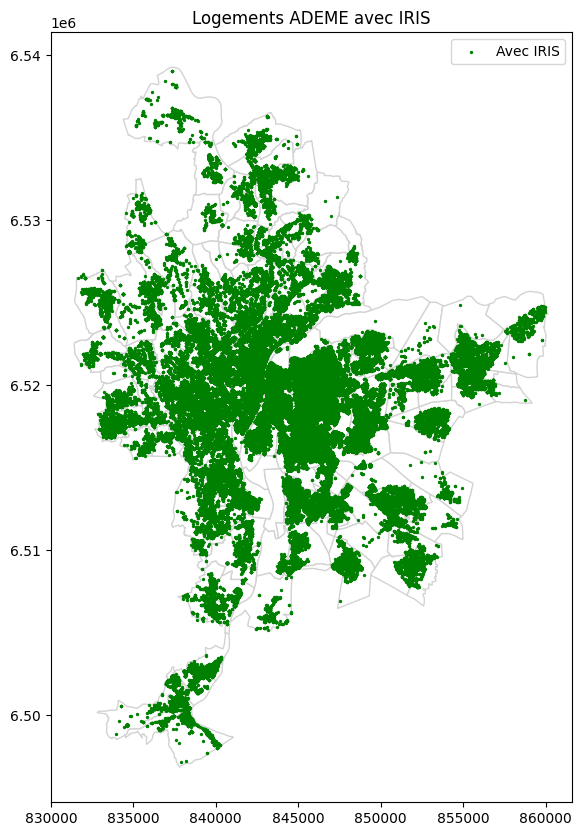

In [85]:
fig, ax = plt.subplots(figsize=(10, 10))

# Fond de carte IRIS
gdf_iris.plot(ax=ax, color="white", edgecolor="lightgray")

# Points ADEME valides (verts)
gdf_adem_valid.plot(ax=ax, color="green", markersize=2, label="Avec IRIS")

plt.legend()
plt.title("Logements ADEME avec IRIS")
plt.show()


### 06. Répartition des logements ADEME par IRIS

In [87]:
df_iris_counts = (
    gdf_adem_valid.groupby("codeiris")
    .size()
    .reset_index(name="nb_logements")
    .sort_values("nb_logements", ascending=False)
    .merge(
        gdf_iris[["codeiris", "commune"]],
        on="codeiris",
        how="left"
    )
)

df_iris_counts["commune"] = (
    df_iris_counts["commune"]
    .astype(str)
    .apply(lambda x: x.encode("latin1", errors="ignore").decode("utf8", errors="ignore"))
)


df_iris_counts.head(10)

,codeiris,nb_logements,commune
0,693870601.0,4302,Lyon 7e Arrondissement
1,693850301.0,3800,Lyon 5e Arrondissement
2,692860401.0,3096,Rillieux-la-Pape
3,693830302.0,2898,Lyon 3e Arrondissement
4,692661204.0,2576,Villeurbanne
5,692590601.0,2118,Vénissieux
6,692860202.0,2012,Rillieux-la-Pape
7,693890401.0,1971,Lyon 9e Arrondissement
8,693880901.0,1965,Lyon 8e Arrondissement
9,693890302.0,1959,Lyon 9e Arrondissement


### 07. ENEDIS agrégé par IRIS

In [92]:
df_enedis_group = (
    df_enedis.groupby("code_iris")
    .agg({
        "conso_totale_mwh": "sum",
        "conso_moy_site_mwh": "mean",
        "conso_moy_commune_mwh": "mean",
        "nombre_de_logements": "sum"
    })
    .reset_index()
)
print("ENEDIS agrégé par IRIS :", df_enedis_group.shape)
df_enedis_group.head()


ENEDIS agrégé par IRIS : (641, 5)


,code_iris,conso_totale_mwh,conso_moy_site_mwh,conso_moy_commune_mwh,nombre_de_logements
0,690030000,6429.986,2.725961,4.559143,2741
1,690060101,1474.476,1.642021,4.130667,913
2,690060102,1200.127,2.005750,4.140212,581
3,690070000,1397.587,2.978172,6.102448,445
4,690090000,10806.683,2.680710,5.110584,4240


In [ ]:
(df_enedis_group.isna().mean() * 100).sort_values(ascending=False)

code_iris                0.0
conso_totale_mwh         0.0
conso_moy_site_mwh       0.0
conso_moy_commune_mwh    0.0
nombre_de_logements      0.0
dtype: float64

### 08. Merge ADEM x ENEDIS

In [100]:
# Harmoniser les types de clés pour la fusion
gdf_adem_valid["codeiris"] = gdf_adem_valid["codeiris"].astype(str).str.split(".").str[0]
df_enedis_group["code_iris"] = df_enedis_group["code_iris"].astype(str).str.split(".").str[0]

# Vérif rapide
print("Type ADEME :", gdf_adem_valid["codeiris"].dtype)
print("Type ENEDIS :", df_enedis_group["code_iris"].dtype)

Type ADEME : object
Type ENEDIS : object


In [123]:
df_merge_iris = gdf_adem_valid.merge(
    df_enedis_group,
    how="left",
    left_on="codeiris",
    right_on="code_iris"
)

print("Shape fusion :", df_merge_iris.shape)

match_rate = df_merge_iris["conso_moy_site_mwh"].notna().mean() * 100
print(f"Taux de correspondance ADEME ↔ ENEDIS (via IRIS) : {match_rate:.2f}%")

Shape fusion : (360897, 44)
Taux de correspondance ADEME ↔ ENEDIS (via IRIS) : 99.28%


In [119]:
df_merge_iris = df_merge_iris.dropna(subset=["conso_moy_site_mwh"])
print(f"Nouvelle taille du dataset : {df_merge_iris.shape}")

Nouvelle taille du dataset : (358302, 44)


In [121]:
cols_to_drop = [
    "geometry", "index_right", "has_iris", "code_iris"
]

df_final = df_merge_iris.drop(columns=cols_to_drop, errors="ignore").copy()

# Vérif finale
print("Nombre de colonnes finales :", len(df_final.columns))
print("Nombre de lignes :", df_final.shape[0])
df_final.head(3)

Nombre de colonnes finales : 40
Nombre de lignes : 358302


,conso_5_usages_ep,emission_ges_5_usages,nom_commune_ban,type_logement_source,cout_total_5_usages,etiquette_ges,methode_application_dpe,type_energie_principale_chauffage,code_region_ban,conso_refroidissement_ep,...,code_postal_ban,zone_climatique,qualite_isolation_menuiseries,date_reception_dpe,emission_ges_chauffage,codeiris,conso_totale_mwh,conso_moy_site_mwh,conso_moy_commune_mwh,nombre_de_logements
0,16721.9,547.5,ALBIGNY-SUR-SAÔNE,EXISTANT,1238.0,C,DPE APPARTEMENT INDIVIDUEL,ÉLECTRICITÉ,84.0,0.0,...,69250,H1C,INSUFFISANTE,2022-04-02,10.6,690030000,6429.986,2.725961,4.559143,2741.0
1,28697.8,6286.9,ALBIGNY-SUR-SAÔNE,EXISTANT,2174.0,F,DPE APPARTEMENT INDIVIDUEL,GAZ NATUREL,84.0,0.0,...,69250,H1C,MOYENNE,2022-06-23,25.4,690030000,6429.986,2.725961,4.559143,2741.0
2,7437.8,1435.8,NEUVILLE-SUR-SAÔNE,EXISTANT,756.7,C,DPE APPARTEMENT INDIVIDUEL,GAZ NATUREL,84.0,0.0,...,69250,H1C,BONNE,2022-06-07,955.9,691430104,7800.521,2.302478,3.265994,3366.0


In [122]:
output_path = "../data/df_adem_enedis_iris_69.csv"
df_final.to_csv(output_path, index=False, encoding="utf-8")
print(f"Fichier final enregistré : {output_path}")

Fichier final enregistré : ../data/df_adem_enedis_iris_69.csv
